In [2]:
# Import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import shapiro, ttest_ind

df = pd.read_csv("dataset_smartphones.csv")

# Data Cleaning & Preparation

In [2]:
# Data inspection
df.shape

(50, 14)

In [3]:
# Data inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   model              50 non-null     object
 1   brand              50 non-null     object
 2   price_eur          50 non-null     int64 
 3   price_segment      50 non-null     object
 4   release_year       50 non-null     int64 
 5   ram                50 non-null     int64 
 6   storage            50 non-null     int64 
 7   battery            50 non-null     int64 
 8   charging_speed     50 non-null     int64 
 9   wireless_charging  50 non-null     object
 10  main_camera        50 non-null     int64 
 11  weight             50 non-null     int64 
 12  ppi_density        50 non-null     int64 
 13  antutu_score       50 non-null     int64 
dtypes: int64(10), object(4)
memory usage: 5.6+ KB


In [4]:
# First rows
df.head()

,model,brand,price_eur,price_segment,release_year,ram,storage,battery,charging_speed,wireless_charging,main_camera,weight,ppi_density,antutu_score
0,Galaxy S21 Ultra,Samsung,232,low,2021,12,128,5000,25,yes,108,227,515,657150
1,Redmi Note 10 Pro,Xiaomi,187,low,2021,6,128,5020,33,no,108,193,395,295442
2,Poco F3,Xiaomi,227,low,2021,8,256,4520,33,no,48,196,395,631850
3,iPhone 13 Pro Max,Apple,436,mid,2021,6,128,4352,23,yes,12,240,458,801691
4,Xiaomi 12 Pro,Xiaomi,331,mid,2021,12,256,4600,120,yes,50,204,521,985226


In [5]:
# Check for missing values
df.isna().sum()

,0
model,0
brand,0
price_eur,0
price_segment,0
release_year,0
ram,0
storage,0
battery,0
charging_speed,0
wireless_charging,0


In [4]:
# Handle missing values
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include="number").columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

In [5]:
# Outlier detection using IQR

num_cols = df_clean.select_dtypes(include="number").columns

outlier_summary = {}

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

print("Outlier count per numerical variable:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")

Outlier count per numerical variable:
price_eur: 1
release_year: 0
ram: 0
storage: 11
battery: 6
charging_speed: 0
main_camera: 15
weight: 0
ppi_density: 0
antutu_score: 0


In [7]:
# Encode categorical variables
wc_dummies = pd.get_dummies(df_clean["wireless_charging"], prefix="wc")

df_clean = pd.concat([df_clean, wc_dummies], axis=1)
df_clean["wireless_charging_bin"] = df_clean["wc_yes"]

# Exploratory Data Analysis (EDA)

In [8]:
# Summary statistics for numerical variables
df_clean.describe()

,price_eur,release_year,ram,storage,battery,charging_speed,main_camera,weight,ppi_density,antutu_score
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000e+01
mean,535.10000,2023.280000,9.200000,259.840000,4693.500000,44.940000,68.640000,201.580000,435.520000,1.251493e+06
std,374.61105,1.355864,2.941609,147.656435,722.787666,26.812585,48.805219,25.440679,48.303564,7.026224e+05
min,112.00000,2021.000000,4.000000,64.000000,2018.000000,20.000000,12.000000,144.000000,326.000000,2.793420e+05
25%,228.25000,2022.000000,8.000000,128.000000,4400.000000,25.000000,48.000000,187.250000,395.000000,6.639425e+05
50%,456.50000,2023.000000,8.000000,256.000000,4911.500000,33.000000,50.000000,198.500000,446.000000,1.185406e+06
75%,726.75000,2024.000000,12.000000,256.000000,5000.000000,67.000000,50.000000,220.500000,460.000000,1.715044e+06
max,1569.00000,2025.000000,16.000000,512.000000,6410.000000,120.000000,200.000000,263.000000,552.000000,3.023050e+06


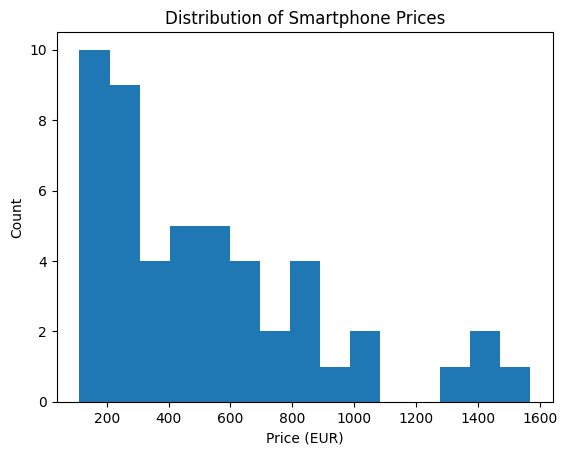

In [9]:
# Histogram of price distribution
plt.hist(df_clean["price_eur"], bins=15)
plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price (EUR)")
plt.ylabel("Count")
plt.show()

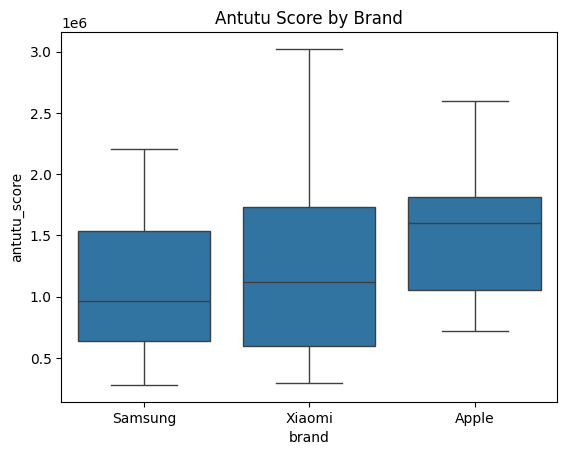

In [10]:
# Boxplot to compare Antutu scores across brands
sns.boxplot(x="brand", y="antutu_score", data=df_clean)
plt.title("Antutu Score by Brand")
plt.show()

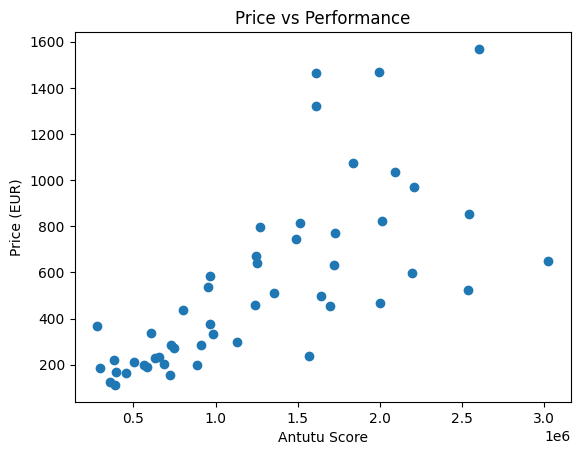

In [11]:
# Scatter plot between performance and price
plt.scatter(df_clean["antutu_score"], df_clean["price_eur"])
plt.xlabel("Antutu Score")
plt.ylabel("Price (EUR)")
plt.title("Price vs Performance")
plt.show()

# One Way Anova

In [12]:
df_upper = df_clean[df_clean["price_segment"].isin(["mid", "high"])].copy()

print("Brand counts:")
print(df_upper["brand"].value_counts())

Brand counts:
brand
Xiaomi     11
Samsung    11
Apple       9
Name: count, dtype: int64


In [13]:
# Normality check (Shapiro-Wilk)
print("\nNormality test for each brand group:\n")
alpha = 0.05

for brand, subdf in df_upper.groupby("brand"):
    stat, p = shapiro(subdf["antutu_score"])
    print(f"Group: brand = {brand}")
    print(f"  W = {stat:.4f}, p = {p:.4f}")

    if p > alpha:
        print("  Fail to reject H0: approximately normal\n")
    else:
        print("  Reject H0: not normal\n")


Normality test for each brand group:

Group: brand = Apple
  W = 0.9748, p = 0.9322
  Fail to reject H0: approximately normal

Group: brand = Samsung
  W = 0.9532, p = 0.6853
  Fail to reject H0: approximately normal

Group: brand = Xiaomi
  W = 0.9748, p = 0.9306
  Fail to reject H0: approximately normal



In [14]:
# ANOVA test
group1 = df_upper[df_upper["brand"] == "Apple"]["antutu_score"]
group2 = df_upper[df_upper["brand"] == "Samsung"]["antutu_score"]
group3 = df_upper[df_upper["brand"] == "Xiaomi"]["antutu_score"]

f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("One-way ANOVA results:")
print(f"  F-statistic = {f_stat:.4f}")
print(f"  p-value = {p_value:.4f}")

if p_value > alpha:
    print("  No significant difference between brands (fail to reject H0)")
else:
    print("  Significant difference between brands (reject H0)")

One-way ANOVA results:
  F-statistic = 0.7141
  p-value = 0.4983
  No significant difference between brands (fail to reject H0)


# Welch t-test

In [15]:
df_low = df_clean[df_clean["price_segment"] == "low"].copy()

print("Wireless charging counts (low segment):")
print(df_low["wireless_charging"].value_counts())

Wireless charging counts (low segment):
wireless_charging_bin
False    14
True      5
Name: count, dtype: int64


In [16]:
# Welch t-test
for label, subdf in df_low.groupby("wireless_charging_bin"):
    stat, p = shapiro(subdf["price_eur"])
    group_name = "With wireless charging" if label == 1 else "Without wireless charging"

    print(f"Group: {group_name}")
    print(f"  W = {stat:.4f}, p = {p:.4f}")

    if p > alpha:
        print("  Fail to reject H0: approximately normal\n")
    else:
        print("  Reject H0: not normal\n")

Group: Without wireless charging
  W = 0.9620, p = 0.7563
  Fail to reject H0: approximately normal

Group: With wireless charging
  W = 0.9761, p = 0.9130
  Fail to reject H0: approximately normal



In [17]:
price_wc = df_low[df_low["wireless_charging_bin"] == 1]["price_eur"]
price_no_wc = df_low[df_low["wireless_charging_bin"] == 0]["price_eur"]

t_stat, p_value = ttest_ind(price_wc, price_no_wc, equal_var=False)

print("Welch two-sample t-test results:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")

if p_value > alpha:
    print("  No significant difference in mean price\n")
else:
    print("  Significant difference in mean price\n")

Welch two-sample t-test results:
  t-statistic = 1.0315
  p-value = 0.3404
  No significant difference in mean price



# Multiple Linear Regression

In [18]:
# Multiple Linear Regression
X = df_clean[["antutu_score", "ram", "storage", "battery", "charging_speed", "ppi_density", "weight", "release_year", "main_camera"]]
y = df_clean["price_eur"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Model performance:")
print(f"  R² = {r2:.3f}")
print(f"  MAE = {mae:.2f} EUR")

Model performance:
  R² = 0.118
  MAE = 218.57 EUR


In [19]:
coef_plot_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient")

coef_plot_df

,Feature,Coefficient
4,charging_speed,-141.876066
1,ram,-57.009570
3,battery,-34.052131
5,ppi_density,-25.755944
7,release_year,15.889495
8,main_camera,63.833206
6,weight,79.809633
2,storage,216.168090
0,antutu_score,256.935591


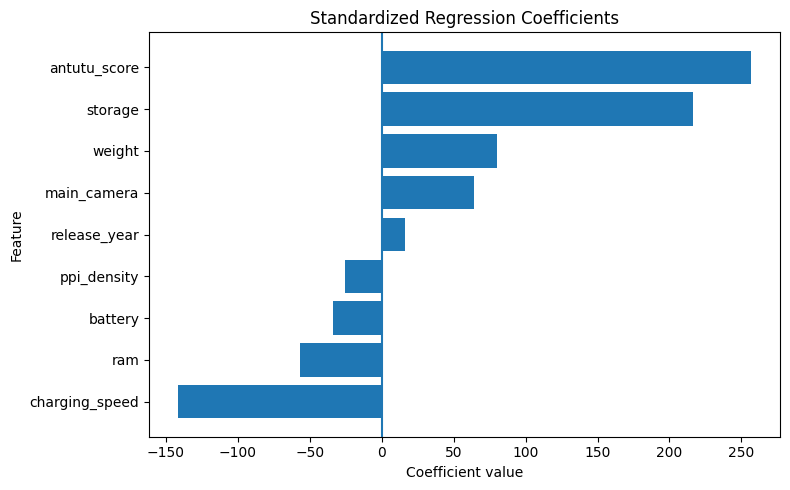

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.barh(coef_plot_df["Feature"], coef_plot_df["Coefficient"])
plt.axvline(0)
plt.title("Standardized Regression Coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()